In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv("../data/train.csv")

In [3]:
df.sample(4)

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
944054,id2717766,2,2016-05-13 14:36:40,2016-05-13 15:08:00,2,-73.993721,40.749920,-74.005554,40.725628,N,1880
314692,id0247048,1,2016-04-11 19:43:33,2016-04-11 19:59:29,1,-73.965210,40.766380,-73.993500,40.724617,N,956
1326341,id1230987,1,2016-02-29 15:37:05,2016-02-29 15:44:32,1,-73.970032,40.794785,-73.980438,40.781605,N,447
1034351,id0618105,2,2016-02-17 06:33:18,2016-02-17 06:37:37,6,-73.992508,40.763329,-73.993683,40.752151,N,259


In [4]:
def calc_distance(pickup_lat, pickup_long, dropoff_lat, dropoff_long):
    
    pickup_lat = np.radians(pickup_lat)
    pickup_long = np.radians(pickup_long)
    
    dropoff_lat = np.radians(dropoff_lat)
    dropoff_long = np.radians(dropoff_long)
    
    dlat = dropoff_lat - pickup_lat
    dlong = dropoff_long - pickup_long
    
    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(pickup_lat)
        * np.cos(dropoff_lat)
        * np.sin(dlong / 2) ** 2
    )
    
    c = 2 * np.arcsin(np.sqrt(a))
    
    distance_km = 6371 * c
    
    return distance_km

In [5]:
df['distance_km'] = df.apply(
    lambda x: calc_distance(
        x['pickup_latitude'],
        x['pickup_longitude'],
        x['dropoff_latitude'],
        x['dropoff_longitude']
    ),
    axis=1
)

In [6]:
df.sample(5)

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,distance_km
1117351,id1271684,2,2016-04-23 19:23:18,2016-04-23 19:39:31,6,-73.965996,40.794727,-73.995720,40.759014,N,973,4.694060
803704,id3673368,2,2016-04-16 18:18:28,2016-04-16 18:25:21,1,-73.978722,40.750038,-73.987732,40.760220,N,413,1.362976
1050710,id1453294,1,2016-05-03 17:09:45,2016-05-03 17:17:16,2,-73.962013,40.773933,-73.971283,40.761250,N,451,1.612015
803474,id1573989,2,2016-04-09 15:52:04,2016-04-09 16:07:12,1,-73.977501,40.764290,-73.984749,40.738628,N,908,2.918010
1186534,id1849883,2,2016-05-27 11:08:09,2016-05-27 11:12:38,3,-73.989548,40.741699,-74.004829,40.736019,N,269,1.434078


In [7]:
import seaborn as sns

<Axes: >

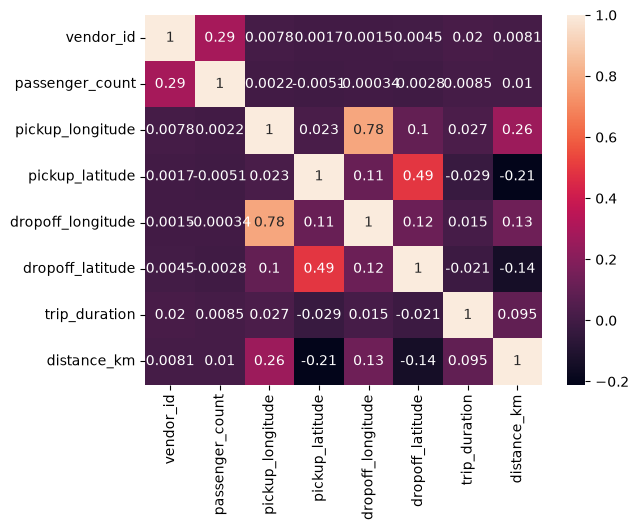

In [8]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [9]:
df['vendor_id'].value_counts()

vendor_id
2    780302
1    678342
Name: count, dtype: int64

In [10]:
print(df.columns.tolist())

['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime', 'passenger_count', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag', 'trip_duration', 'distance_km']


In [12]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# -----------------------------
# Load data
# -----------------------------



# -----------------------------
# Datetime features
# -----------------------------

df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

df['pickup_hour'] = df['pickup_datetime'].dt.hour
df['pickup_dayofweek'] = df['pickup_datetime'].dt.dayofweek
df['pickup_month'] = df['pickup_datetime'].dt.month

df['is_weekend'] = (df['pickup_dayofweek'] >= 5).astype(int)

df['is_rush_hour'] = (
    df['pickup_hour'].isin([7, 8, 9, 17, 18, 19])
).astype(int)


# -----------------------------
# Convert categorical column
# -----------------------------

df['store_and_fwd_flag'] = (
    df['store_and_fwd_flag'] == 'Y'
).astype(int)


# -----------------------------
# Features
# -----------------------------

features = [
    'vendor_id',
    'passenger_count',
    'pickup_longitude',
    'pickup_latitude',
    'dropoff_longitude',
    'dropoff_latitude',
    'distance_km',
    'pickup_hour',
    'pickup_dayofweek',
    'pickup_month',
    'is_weekend',
    'is_rush_hour',
    'store_and_fwd_flag'
]

X = df[features]
y = df['trip_duration']


# -----------------------------
# Train Test Split
# -----------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# -----------------------------
# Model
# -----------------------------

model = LinearRegression()

model.fit(X_train, y_train)


# -----------------------------
# Prediction
# -----------------------------

y_pred = model.predict(X_test)


# -----------------------------
# Evaluation
# -----------------------------

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)


print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 463.56289342773965
RMSE: 3212.1725540928824
R2  : 0.02584905648333813
